### 1. Data Loading and Data Engineering



In [1]:
# Import the data manipulation and visualization libraries, as well as the machine learning tools from scikit-learn.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso,ElasticNet, HuberRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from scipy import stats
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error, mean_squared_error
import re


In [2]:
DATA_PATH = "../survey_results_public.csv" # Path to the dataset. Adjust this path if your dataset is located elsewhere.

In [3]:
DACH_COUNTRIES = ["Germany", "Austria", "Switzerland"] # List of DACH countries to filter the dataset by.

BRANCH_DEVELOPERS = "I am a developer by profession" # Filter for responders who are developers by profession.

SALARY_MIN = 15_000 # Minimum salary threshold. Salaries below this value will be considered outliers and removed from the dataset.
SALARY_MAX = 400_000 # Maximum salary threshold. Salaries above this value will be considered outliers and removed from the dataset.

NON_WORK_YEARS = 15 # Work experience cannot be more than responder's age minus NON_WORK_YEARS. This aims to filter out unrealistic work experience values.
NON_CODER_AGE = 7 # Minimum age for a responder to start coding. Responders that codes longer than age minus NON_CODER_AGE will be considered outliers.

RANDOM_STATE = 42 
N_SPLITS = 5 # Number of splits for K-Fold cross-validation.

# IQR multiplier for salary outlier filtering. 
OUTLIER_IQR_MULT = 1.5

# List of columns to drop from the dataset. Commented columns will not be dropped.
# chris: reduced columns further for fitting to TabPFN 
DROP_COLS = [   'ResponseId', 
                'MainBranch', 
                 # 'Age', 
                 # 'EdLevel', 
                 # 'Employment', 
                'EmploymentAddl', 
                 # 'WorkExp', 
                 # 'LearnCodeChoose', 
                'LearnCode', 
                #'LearnCodeAI', 
                'AILearnHow', 
                'YearsCode', 
                # 'DevType', 
                # 'OrgSize', 
                # 'ICorPM', 
                # 'RemoteWork', 
                # 'PurchaseInfluence', 
                'TechEndorseIntro', 'TechEndorse_1', 'TechEndorse_2', 'TechEndorse_3', 'TechEndorse_4', 'TechEndorse_5', 'TechEndorse_6', 
                'TechEndorse_7', 'TechEndorse_8', 'TechEndorse_9', 'TechEndorse_13', 'TechEndorse_13_TEXT', 
                'TechOppose_1', 'TechOppose_2', 'TechOppose_3', 'TechOppose_5', 'TechOppose_7', 'TechOppose_9',
                'TechOppose_11', 'TechOppose_13', 'TechOppose_16', 'TechOppose_15', 'TechOppose_15_TEXT', 
                # 'Industry', 
                'JobSatPoints_1', 'JobSatPoints_2', 'JobSatPoints_3', 'JobSatPoints_4', 'JobSatPoints_5', 
                'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10', 'JobSatPoints_11', 
                'JobSatPoints_13', 'JobSatPoints_14', 'JobSatPoints_15', 'JobSatPoints_16', 'JobSatPoints_15_TEXT', 
                'AIThreat', 
                'NewRole', 
                # 'ToolCountWork', 
                # 'ToolCountPersonal', 
                # 'Country', 
                'Currency', 'CompTotal', 
                # 'LanguageChoice', 
                # 'LanguageHaveWorkedWith', 
                'LanguageWantToWorkWith', 
                'LanguageAdmired', 
                'LanguagesHaveEntry', 
                'LanguagesWantEntry', 
                # 'DatabaseChoice', 
                'DatabaseHaveWorkedWith', 
                'DatabaseWantToWorkWith', 
                'DatabaseAdmired', 
                'DatabaseHaveEntry', 
                'DatabaseWantEntry', 
                # 'PlatformChoice', 
                'PlatformHaveWorkedWith', 
                'PlatformWantToWorkWith', 
                'PlatformAdmired', 
                'PlatformHaveEntry', 
                'PlatformWantEntry', 
                # 'WebframeChoice', 
                'WebframeHaveWorkedWith', 
                'WebframeWantToWorkWith', 
                'WebframeAdmired', 
                'WebframeHaveEntry', 
                'WebframeWantEntry',
                # 'DevEnvsChoice', 
                # 'DevEnvsHaveWorkedWith', 
                'DevEnvsWantToWorkWith', 
                'DevEnvsAdmired',
                'DevEnvHaveEntry', 
                'DevEnvWantEntry', 
                'SOTagsHaveWorkedWith', 'SOTagsWantToWorkWith', 'SOTagsAdmired', 'SOTagsHaveEntry', 'SOTagsWant Entry', 'OpSysPersonal use', 
                #'OpSysProfessional use', 
                'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith', 'OfficeStackAsyncAdmired', 'OfficeStackHaveEntry', 'OfficeStackWantEntry', 
                'CommPlatformHaveWorkedWith', 'CommPlatformWantToWorkWith', 'CommPlatformAdmired', 'CommPlatformHaveEntr', 'CommPlatformWantEntr', 
                # 'AIModelsChoice', 
                'AIModelsHaveWorkedWith', 
                'AIModelsWantToWorkWith', 
                'AIModelsAdmired', 
                'AIModelsHaveEntry', 
                'AIModelsWantEntry', 
                'SOAccount', 'SOVisitFreq', 'SODuration', 'SOPartFreq', 'SO_Dev_Content', 
                'SO_Actions_1', 'SO_Actions_16', 'SO_Actions_3', 'SO_Actions_4', 'SO_Actions_5', 'SO_Actions_6', 'SO_Actions_9', 'SO_Actions_7', 
                'SO_Actions_10', 'SO_Actions_15', 'SO_Actions_15_TEXT', 'SOComm', 'SOFriction', 
                # 'AISelect', 
                'AISent', 'AIAcc', 
                'AIComplex', 'AIToolCurrently partially AI', 
                "AIToolDon't plan to use AI for this task", 'AIToolPlan to partially use AI', 'AIToolPlan to mostly use AI', 
                'AIToolCurrently mostly AI', 
                'AIFrustration', 'AIExplain', 
                # 'AIAgents', 
                'AIAgentChange', 'AIAgent_Uses', 'AgentUsesGeneral', 
                'AIAgentImpactSomewhat agree', 'AIAgentImpactNeutral', 'AIAgentImpactSomewhat disagree', 'AIAgentImpactStrongly agree', 'AIAgentImpactStrongly disagree', 
                'AIAgentChallengesNeutral', 'AIAgentChallengesSomewhat disagree', 'AIAgentChallengesStrongly agree', 'AIAgentChallengesSomewhat agree', 'AIAgentChallengesStrongly disagree', 
                'AIAgentKnowledge', 'AIAgentKnowWrite', 'AIAgentOrchestration', 'AIAgentOrchWrite', 'AIAgentObserveSecure', 
                'AIAgentObsWrite', 'AIAgentExternal', 'AIAgentExtWrite', 
                'AIHuman', 'AIOpen', 
                # 'ConvertedCompYearly', 
                'JobSat'
            ] 

# Top-N most common values to keep for high-cardinality multi-select fields.
# Everything else gets folded into "other" via the binarizer ignoring it.
TOP_N_LANGUAGES   = 25
TOP_N_DATABASES   = 15
TOP_N_PLATFORMS   = 12
TOP_N_WEBFRAMES   = 20
TOP_N_IDES        = 15
TOP_N_AIMODELS    = 15
TOP_N_OS          = 8
TOP_N_EMPLOYMENT  = 8
TOP_N_LEARN       = 10

# List of categorical columns.
# Chris: commented out columns that overlap with YES_NO_COLS below, and will override transformation to 0/1
# chris: added Employment as categorial variables instead of multi-select
CATEGORICAL_COLS = [
    "Country", "EdLevel", "DevType", "OrgSize", "ICorPM", "RemoteWork",
    "PurchaseInfluence", 
    "Industry", "AIThreat",
    "LanguageChoice", "DatabaseChoice", "PlatformChoice", "WebframeChoice",
    "DevEnvsChoice", "AIModelsChoice",
    "AISelect", 
    "AIComplex", 
    "AIAgents",
    "AIAgentKnowledge", "AIAgentOrchestration",
    "AIAgentObserveSecure", "AIAgentExternal",
    # "LanguageHaveWorkedWith",
    "Employment",
]

# chris: count the number of values in these columns
COUNTING_COLS = [
    "LanguageHaveWorkedWith",
]

# List of yes/no columns to be mapped to 1/0.
YES_NO_COLS = ["LearnCodeAI", 
               "LearnCodeChoose", "PurchaseInfluence", "LanguageChoice", "DatabaseChoice", "PlatformChoice", "WebframeChoice", "DevEnvsChoice", 
                "AIModelsChoice",  "SOAccount", "SOComm",
               "AISelect", "AIExplain", "AIAgents", "AIAgentChange", "LearnAI"
               ]

# Multi-select (semicolon-separated) → multi-hot encoded with top-N
MULTI_SELECT_SPECS = [
    # chris: counting the number of values instead (["LanguageHaveWorkedWith", "LanguagesHaveEntry"], "lang",    TOP_N_LANGUAGES),
    (["DatabaseHaveWorkedWith", "DatabaseHaveEntry"],  "db",      TOP_N_DATABASES),
    (["PlatformHaveWorkedWith", "PlatformHaveEntry"],  "plat",    TOP_N_PLATFORMS),
    (["WebframeHaveWorkedWith", "WebframeHaveEntry"],  "web",     TOP_N_WEBFRAMES),
    (["DevEnvsHaveWorkedWith",  "DevEnvHaveEntry"],    "ide",     TOP_N_IDES),
    (["AIModelsHaveWorkedWith", "AIModelsHaveEntry"],  "aimodel", TOP_N_AIMODELS),
    (["OpSysProfessional use"],                        "os",      TOP_N_OS),
    # chris: this should be a categorial column instead (["Employment"],                                   "emp",     TOP_N_EMPLOYMENT),
]

# Grouped languages with frequency more than 5
LANGUAGE_GROUPS = {
    # Web frontend trio
    "web_frontend":   ["JavaScript", "TypeScript", "HTML/CSS"],

    # Data / scientific computing
    "data_science":   ["Python", "R", "MATLAB"],

    # Shell + query glue (sysadmin / DBA signal)
    "query_shell":    ["SQL", "Bash/Shell (all shells)", "PowerShell"],

    # JVM ecosystem
    "jvm":            ["Java", "Kotlin", "Scala", "Groovy", "Clojure"],

    # .NET ecosystem
    "dotnet":         ["C#", "F#", "Visual Basic (.NET)", "VBA"],

    # Systems / low-level
    "systems":        ["C", "C++", "Rust", "Zig", "Assembly"],

    # Modern backend (PHP/Ruby legacy + Go/Elixir/Erlang modern)
    "web_backend":    ["PHP", "Ruby", "Go", "Elixir", "Erlang"],

    # Mobile native
    "mobile":         ["Swift", "Objective-C", "Dart"],
}

# Grouped databases with frequency more than 5
DATABASE_GROUPS = {
    # Traditional relational SQL — the workhorses
    "sql_relational": [
        "PostgreSQL", "MySQL", "MariaDB", "SQLite",
        "Microsoft SQL Server", "Oracle", "IBM DB2",
        "Microsoft Access", "H2", "Firebird",
    ],

    # Cloud warehouses + distributed SQL
    "sql_cloud_warehouse": [
        "BigQuery", "Snowflake", "Amazon Redshift", "Databricks SQL",
        "Cockroachdb", "SAP HANA",
    ],

    # NoSQL document stores + BaaS DBs
    "nosql_document": [
        "MongoDB", "Dynamodb", "Cosmos DB",
        "Cloud Firestore", "Firebase Realtime Database",
        "Couchdb", "Pocketbase", "Supabase", "RavenDB",
    ],

    # Key-value / caches
    "kv_cache": ["Redis", "Valkey"],

    # Search + columnar analytics
    "search_analytics": ["Elasticsearch", "Clickhouse", "DuckDB", "Meilisearch"],

    # Specialty NoSQL — time-series, graph, wide-column
    "nosql_specialty": ["InfluxDB", "Neo4J", "Cassandra"],
}

# Grouped platforms with frequency more than 5
PLATFORM_GROUPS = {
    # Big-3 hyperscalers
    "hyperscaler_cloud": [
        "Amazon Web Services (AWS)", "Microsoft Azure", "Google Cloud",
    ],

    # Other cloud + PaaS + BaaS
    "other_cloud": [
        "Cloudflare", "Digital Ocean", "IBM Cloud",
        "Heroku", "Railway", "Vercel", "Netlify",
        "Firebase", "Supabase",
    ],

    # Containers / Kubernetes
    "containers": [
        "Docker", "Kubernetes", "Podman",
    ],

    # Infrastructure as Code + config management
    "iac": [
        "Ansible", "Terraform", "Pulumi",
    ],

    # Observability / monitoring
    "observability": [
        "Datadog", "New Relic", "Prometheus", "Splunk",
    ],

    # Build tools (compiled languages + JS bundlers)
    "build_tools": [
        "Make", "CMake", "Gradle", "Maven (build tool)", "MSBuild", "Ninja",
        "Cargo", "Vite", "Webpack", "Bun",
    ],

    # Language-level package managers
    "pkgmgr_lang": [
        "npm", "Yarn", "pnpm", "Pip", "Poetry", "uv",
        "NuGet", "Composer",
    ],

    # OS-level package managers
    "pkgmgr_os": [
        "APT", "Pacman", "Homebrew", "Chocolatey", "Nix",
    ],
}

# Grouped web frameworks with frequency more than 5
WEBFRAME_GROUPS = {
    # All JS UI frameworks — modern + legacy together
    "js_frontend": ["React", "Angular", "Vue.js", "Svelte", "Astro",
                    "SolidJS", "SvelteKit", "AngularJS", "jQuery"],

    # JS server-side / meta-frameworks
    "js_backend":  ["Node.js", "Express", "NestJS", "Fastify",
                    "Next.js", "Nuxt.js", "Deno"],

    # Python (web + data apps together)
    "python_web":  ["Django", "Flask", "FastAPI", "Streamlit"],

    # JVM (modern + legacy together)
    "jvm_web":     ["Spring Boot", "Quarkus", "Vaadin"],

    # .NET
    "dotnet_web":  ["ASP.NET", "ASP.NET Core", "Blazor"],

    # PHP (frameworks + CMSes together)
    "php_web":     ["Laravel", "Symfony", "WordPress", "Drupal", "TYPO3"],

    # Rust web
    "rust_web":    ["Axum", "Actix", "Dioxus", "Leptos"],
}

# Grouped IDEs with frequency more than 5
IDE_GROUPS = {
    # Modern general-purpose editors (VS Code dominant; Cursor goes in ai_editor instead)
    "modern_general":  ["Visual Studio Code", "VSCodium", "Zed", "Sublime Text"],

    # AI-assisted editors (early-adopter / productivity signal)
    "ai_editor":       ["Cursor", "Claude Code", "Windsurf",
                        "Cline and/or Roo", "Aider", "Bolt",
                        "Lovable.dev", "Trae"],

    # JetBrains IDE family (paid, enterprise signal — incl. Android Studio)
    "jetbrains":       ["IntelliJ IDEA", "PyCharm", "WebStorm", "Rider",
                        "PhpStorm", "RustRover", "Android Studio"],

    # Terminal editors with vi keybindings (power-user / senior signal)
    "vim_family":      ["Vim", "Neovim"],

    # Platform-locked heavyweight IDEs (each forces a specific stack/OS)
    "platform_ide":    ["Visual Studio", "Xcode", "Eclipse"],

    # Notebooks (data-scientist signal)
    "notebook":        ["Jupyter Notebook/JupyterLab"],

    # Lightweight quick-edit tools (Windows admins, casual coders)
    "lightweight":     ["Notepad++", "Nano"],
}

# Grouped AI models with frequency more than 5
MODEL_GROUPS = {
    # OpenAI ecosystem
    "openai": [
        "OpenAI GPT (chatbot models)",
        "OpenAI reasoning models",
        "OpenAI image generating models",
    ],

    # Google Gemini ecosystem
    "gemini": [
        "Gemini Flash (general purpose models)",
        "Gemini Pro (reasoning models)",
    ],

    # Anthropic models
    "anthropic": [
        "Claude Sonnet",
    ],

    # DeepSeek ecosystem
    "deepseek": [
        "DeepSeek R (reasoning models)",
        "DeepSeek V (general purpose models)",
    ],

    # Meta open-weight models
    "meta": [
        "Meta Llama (all models)",
    ],

    # Mistral AI
    "mistral": [
        "Mistral AI models",
    ],

    # Perplexity
    "perplexity": [
        "Perplexity Sonar models",
    ],

    # xAI
    "xai": [
        "x Grok models",
    ],

    # Alibaba ecosystem
    "alibaba": [
        "Alibaba Cloud Qwen models",
    ],

    # Microsoft small models
    "microsoft": [
        "Microsoft Phi-4 models",
    ],

    # Amazon foundation models
    "amazon": [
        "Amazon Titan models",
    ],
}

# List of groups for multi-select fields. Each group maps a column prefix to a set of related values. 
# IF YOU WANT TOP-N BINARIZATION, MAKE SURE COMMENT THIS OUT.
GROUPS_BY_PREFIX = {
    "lang": LANGUAGE_GROUPS,
    "db":   DATABASE_GROUPS,
    "plat": PLATFORM_GROUPS,
    "webframe": WEBFRAME_GROUPS,
    "ide": IDE_GROUPS,
    "model": MODEL_GROUPS,
}

In [4]:
def load_dach(path) -> pd.DataFrame:

    """Loads the dataset, filters for DACH countries, and applies basic cleaning steps like removing rows without salary or with implausible salary values."""

    # Load the dataset from the specified path.
    df = pd.read_csv(path)
    print(f"Loaded {len(df):,} total responses")

    # Filter the dataset to include only respondents from DACH countries who are developers by profession.
    df = df[(df["Country"].isin(DACH_COUNTRIES)) & (df['MainBranch'] == BRANCH_DEVELOPERS)].copy()
    print(f"DACH subset: {len(df):,} responses")
    print(df["Country"].value_counts().to_string())

    # Drop rows without salary or with implausible values.
    df = df.dropna(subset=["ConvertedCompYearly"])
    df = df[df["ConvertedCompYearly"].between(SALARY_MIN, SALARY_MAX)]
    print(f"After salary range filter: {len(df):,} responses")

    # Drop columns that are not needed for modeling.
    df = df.drop(columns=DROP_COLS)
    print(f"After column drop: {len(df.columns):,} columns")
   
    return df.reset_index(drop=True)

In [5]:
def parse_age_upper(value) -> float:
    
    """Convert age brackets to the upper bound as a number.
    Example: "25-34 years old" → 34."""

    s = str(value).strip().lower()

    if "prefer not" in s:
        return np.nan
    
    # Pull all integers out of the string, take the largest one.
    nums = [int(n) for n in re.findall(r"\d+", s)]
    if not nums:
        return np.nan
    return float(max(nums))

In [6]:
def clean_outliers(df: pd.DataFrame) -> pd.DataFrame:
    
    """Per-country IQR filtering on log-salary + experience sanity checks. """

    n_in = len(df)
    #print(f"\nOutlier cleaning starting from {n_in:,} responses:")

    # Per-country IQR on log salary.
    log_sal = np.log1p(df["ConvertedCompYearly"])
    keep = pd.Series(True, index=df.index)
    for country in DACH_COUNTRIES:
        mask = (df["Country"] == country).values
        if mask.sum() == 0:
            continue
        q1, q3 = log_sal[mask].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo = q1 - OUTLIER_IQR_MULT * iqr
        hi = q3 + OUTLIER_IQR_MULT * iqr
        outlier_mask = mask & ((log_sal < lo) | (log_sal > hi)).values
        n_dropped = int(outlier_mask.sum())
        keep &= ~outlier_mask
        # Convert log bounds back to USD for the printout.
        #print(
        #    f"  {country:14s}: kept ${np.expm1(lo):>7,.0f}–${np.expm1(hi):>7,.0f}  "
        #    f"(removed {n_dropped} of {int(mask.sum())})"
        #)
    df = df.loc[keep].copy()

    # Add AgeUpper column for the experience sanity check.
    df.loc[:, "AgeUpper"] = df["Age"].apply(parse_age_upper)

    # Experience sanity check. 
    max_exp = df["AgeUpper"] - NON_WORK_YEARS
    df.loc[:, "WorkExp"] = pd.to_numeric(df["WorkExp"], errors="coerce").clip(lower=0, upper=max_exp)

    max_coding_years = df["AgeUpper"] - NON_CODER_AGE
    #df.loc[:, "YearsCode"] = pd.to_numeric(df["YearsCode"], errors="coerce").clip(lower=0, upper=max_coding_years) #marielle: excluding YearsCode 

    df = df.drop(columns=['AgeUpper'], errors="ignore")
    return df.reset_index(drop=True)



In [7]:
def parse_multiselect(value) -> list[str]:

    """Parse a semicolon-separated multi-select field into a list of strings, handling NaN values."""

    if pd.isna(value):
        return []
    return [v.strip() for v in str(value).split(";") if v.strip()]

In [8]:
 
def top_n_binarizer(series: pd.Series, n: int | None) -> tuple[MultiLabelBinarizer, np.ndarray]:
    """Fit a MultiLabelBinarizer. If we use TOP_N technologies - n will be the number of top technologies to include. If n is None, use all distinct classes for grouping."""
    parsed = series.apply(parse_multiselect)
    counts: dict[str, int] = {}
    for items in parsed:
        for item in items:
            counts[item] = counts.get(item, 0) + 1
    sorted_classes = [k for k, _ in sorted(counts.items(), key=lambda kv: -kv[1])]
    top = sorted_classes if n is None else sorted_classes[:n]

    mlb = MultiLabelBinarizer(classes=top)
    parsed_filtered = parsed.apply(lambda items: [i for i in items if i in top])
    matrix = mlb.fit_transform(parsed_filtered)
    return mlb, matrix

In [9]:
def yes_no_binarizer(series: pd.Series) -> np.ndarray:
    """Convert strings containing 'yes' to 1, otherwise 0. NaN -> 0."""
    return (
        series.fillna("")
        .astype(str)
        .str.lower()
        .str.contains("yes")
        .astype(int)
        .values
    )

In [10]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:

    feats = pd.DataFrame(index=df.index)

    # chris: add numeric columns as features
    feats = df.select_dtypes(include='number').copy()

    # Yes/No columns
    for col in YES_NO_COLS:
        if col in df.columns:
            feats[col] = yes_no_binarizer(df[col])
            # chris: for debugging - to catch the overwriting of yes/no processing by categorial processing
            # if col == "PurchaseInfluence":
            #     print(col)
            #     print(feats[col].head().to_string())
            #     print("end")

    # Simple categorical columns
    for col in CATEGORICAL_COLS:
        if col in df.columns:
            feats[col] = df[col].astype("object")

    # chris: counting the number of values in these columns; and create a new column to store the count
    for col in COUNTING_COLS:
        if col in df.columns:
            feats[f"{col}_count"] = (
                    df[col]
                        .fillna('')
                        .astype(str)
                        .str.split(';')
                        .apply(lambda parts: sum(1 for p in parts if p.strip()))
            )
            # chris: for debugging
            # feats[col] = df[col].astype("object")

    # chris: for debugging    
    # print(feats[[f"{col}_count", col]].to_string())

    # Multi-select columns — either grouped OR top-N, never both
    for sources, prefix, n in MULTI_SELECT_SPECS:
        available = [c for c in sources if c in df.columns]
        if not available:
            #print(f"  warning: no columns from {sources}, skipping")
            continue
        
        combined = df[available[0]].fillna("").astype(str)
        for c in available[1:]:
            combined = combined + ";" + df[c].fillna("").astype(str)
            
        
        groups = GROUPS_BY_PREFIX.get(prefix)

        # If groups are defined for this prefix, use them to create group features. Otherwise, do top-N binarization.
        if groups is not None:
            mlb, matrix = top_n_binarizer(combined, None)
            classes_lc = [str(c).lower() for c in mlb.classes_]
            grouped_indices: set[int] = set()

            for group_name, members in groups.items():
                members_lc = {m.lower() for m in members}
                acc = np.zeros(matrix.shape[0], dtype=int)
                for j, cls_lc in enumerate(classes_lc):
                    if cls_lc in members_lc:
                        acc |= matrix[:, j]
                        grouped_indices.add(j)
                feats[f"{prefix}_group_{group_name}"] = acc

            # Everything not in any group → one "other" feature
            other_acc = np.zeros(matrix.shape[0], dtype=int)
            for j in range(len(mlb.classes_)):
                if j not in grouped_indices:
                    other_acc |= matrix[:, j]
            feats[f"{prefix}_group_other"] = other_acc
            
        else:
            # No groups defined, just do top-N binarization as usual.
            mlb, matrix = top_n_binarizer(combined, n)
            for j, cls in enumerate(mlb.classes_):
                safe = (str(cls).strip()
                    .replace(" ", "_").replace("/", "_")
                    .replace(",", "").replace(".", ""))
                feats[f"{prefix}_{safe}"] = matrix[:, j]

    print(f"Built features with {feats.shape[1]} columns")
    return feats

In [11]:
def make_preprocessor(feats: pd.DataFrame) -> ColumnTransformer:

    # Features to impute with the median (numerical)
    numerical_features = feats.select_dtypes(include="number").columns.tolist()

    # Features to impute with the mode and One-Hot Encode (categorical/ordinal)
    categorical_features = feats.select_dtypes(include="object").columns.tolist()

    # A. Numerical Pipeline: Impute with Median
    numerical_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
    ])

    # B. Categorical Pipeline: Impute with Mode, then One-Hot Encode
    categorical_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore')) 
    ])
 
    # C. Combine all steps using ColumnTransformer
    return ColumnTransformer(
        transformers=[
            ('num', numerical_pipeline, numerical_features),
            ('cat', categorical_pipeline, categorical_features)
        ],
        remainder='drop' # Drop all other columns
    )



In [15]:
def residual_analysis(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    residuals = y_true - y_pred
    

    # Summary statistics
    mean_residual = residuals.mean()
    std_residual = residuals.std(ddof=1)

    print(f"Mean residual: {mean_residual:.4f}")
    print(f"Residual std: {std_residual:.4f}")

    if mean_residual > 0:
        print("Overall tendency: UNDER-prediction")
    elif mean_residual < 0:
        print("Overall tendency: OVER-prediction")
    else:
        print("No overall bias detected")

    # One-sample t-test
    t_stat, p_value = stats.ttest_1samp(residuals, 0)

    print("\nBias Test (H0: mean residual = 0)")
    print(f"t-statistic = {t_stat:.4f}")
    print(f"p-value     = {p_value:.4g}")

    if p_value < 0.05:
        if mean_residual > 0:
            print("Significant UNDER-prediction detected.")
        else:
            print("Significant OVER-prediction detected.")
    else:
        print("No statistically significant overall bias.")

    # Residual vs Prediction plot
    plt.figure(figsize=(8, 5))
    plt.scatter(y_pred, residuals, alpha=0.6)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.title("Residuals vs Predicted")
    plt.show()

    # Residual histogram
    plt.figure(figsize=(8, 5))
    plt.hist(residuals, bins=30)
    plt.xlabel("Residual")
    plt.ylabel("Count")
    plt.title("Residual Distribution")
    plt.show()


    # Residual vs Feature
    plt.figure(figsize=(8, 5))
    plt.scatter(y_true, residuals, alpha=0.6)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Actual Compensation")
    plt.ylabel("Residual")
    plt.title(f"Residuals vs Actual Compensation")
    plt.show()

    return residuals

In [13]:
df = load_dach(DATA_PATH)
df = clean_outliers(df)
feats = build_features(df)


X = feats.drop(columns=['ConvertedCompYearly'], errors="ignore")
print("X columns:", X.columns.tolist())

y = np.log1p(df['ConvertedCompYearly'])  

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

pipeline = Pipeline ([
    ('preprocessor',make_preprocessor(X_train)),
    ('model', XGBRegressor( 
                objective='reg:squarederror',
                random_state=RANDOM_STATE
            )
    )
])

param_grid = {
    "model__n_estimators": [300, 500], #The number of boosting rounds (trees).
    "model__max_depth": [2, 3], #The maximum depth of each tree. 
    "model__learning_rate": [0.03, 0.04], #Controls how much each new tree contributes.
    "model__min_child_weight": [3, 5], #Minimum amount of data (technically Hessian weight) required in a child node before a split is allowed.
    "model__subsample": [0.7, 0.8], #Fraction of training rows used to build each tree.
    "model__colsample_bytree": [0.7, 0.8], #The fraction of features to be randomly sampled for each tree.
}

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=kf,
    scoring='r2',
    n_jobs=1,
    verbose=1
)

# Tune on training data only
grid.fit(X_train, y_train)  

#print best params and best CV R2
print("Best params:")
print(grid.best_params_)

print("Best CV R2: ", grid.best_score_)

# Best fitted pipeline
best_model = grid.best_estimator_

# Predict on holdout test set
y_pred = best_model.predict(X_test)
# Convert back to dollars
y_test_dollars = np.expm1(y_test)
preds_dollars = np.expm1(y_pred)

mae  = mean_absolute_error(y_test_dollars, preds_dollars)
mse = mean_squared_error(y_test_dollars, preds_dollars)
rmse = root_mean_squared_error(y_test_dollars, preds_dollars)
r2   = r2_score(y_test_dollars, preds_dollars)   
print("Test MAE:", mae)
print("Test MSE:", mse)
print("Test RMSE:", rmse)
print("Test R2:", r2) 




C:\Users\ReDI\AppData\Local\Temp\ipykernel_12316\2043175917.py:6: DtypeWarning: Columns (56,74,92,97,98,105,109,110,132,162,165) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


Loaded 49,191 total responses
DACH subset: 3,056 responses
Country
Germany        2322
Switzerland     415
Austria         319
After salary range filter: 2,247 responses
After column drop: 27 columns
Built features with 40 columns
X columns: ['WorkExp', 'ToolCountWork', 'ToolCountPersonal', 'LearnCodeAI', 'LearnCodeChoose', 'PurchaseInfluence', 'LanguageChoice', 'DatabaseChoice', 'PlatformChoice', 'WebframeChoice', 'DevEnvsChoice', 'AIModelsChoice', 'AISelect', 'AIAgents', 'Country', 'EdLevel', 'DevType', 'OrgSize', 'ICorPM', 'RemoteWork', 'Industry', 'Employment', 'LanguageHaveWorkedWith_count', 'ide_group_modern_general', 'ide_group_ai_editor', 'ide_group_jetbrains', 'ide_group_vim_family', 'ide_group_platform_ide', 'ide_group_notebook', 'ide_group_lightweight', 'ide_group_other', 'os_Windows', 'os_MacOS', 'os_Ubuntu', 'os_Windows_Subsystem_for_Linux_(WSL)', 'os_Linux_(non-WSL)', 'os_Debian', 'os_iOS', 'os_Android']
Shape of X_train: (1694, 39)
Shape of X_test: (424, 39)
Fitting 5 fo

Mean residual: 728.7296
Residual std: 22643.0120
Overall tendency: UNDER-prediction

Bias Test (H0: mean residual = 0)
t-statistic = 0.6627
p-value     = 0.5079
No statistically significant overall bias.


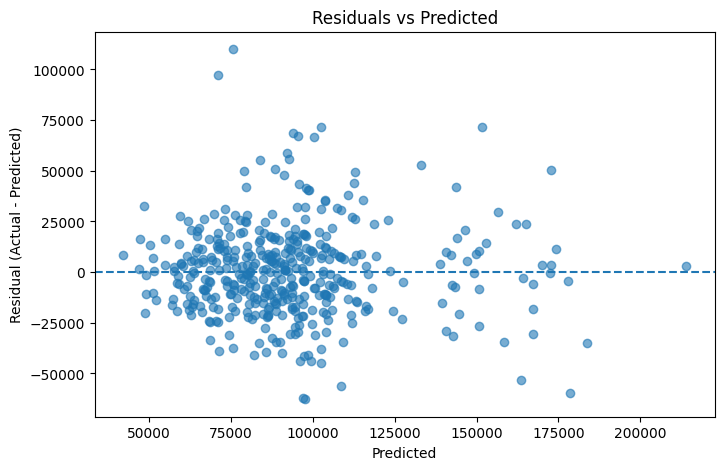

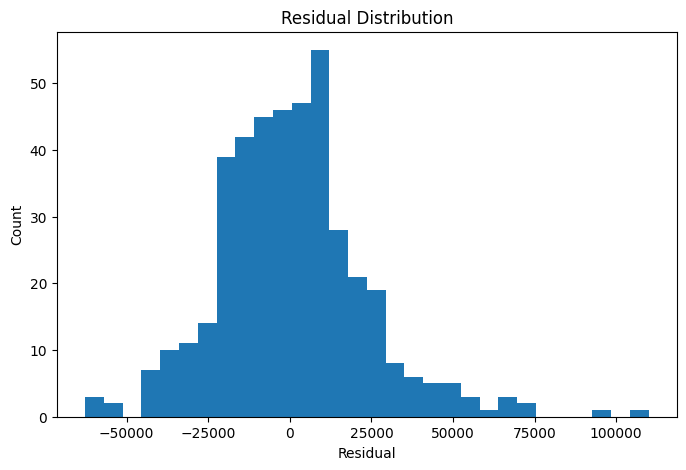

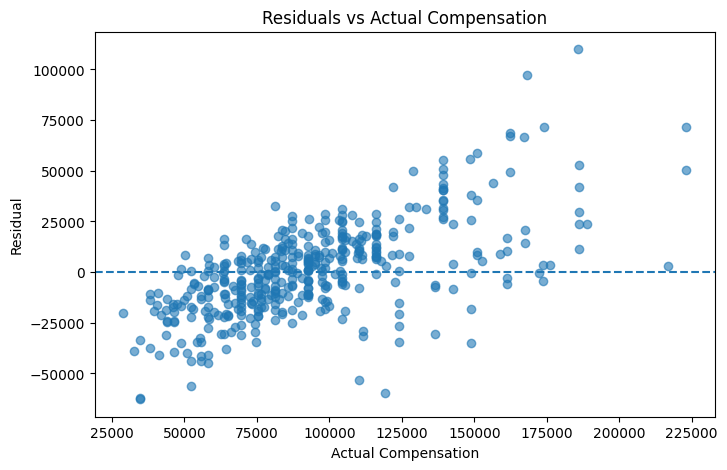

In [16]:
residuals = residual_analysis(y_test_dollars, preds_dollars)

## Comments:
### Residuals
* Residuals = True value - Predicted Value
### Statistics
* Mean residual: 728.7296
* * signals a tendency to under-predict
* Residual std: 22643.0120
* One-sample T-Test (H0: mean residual = 0)
* * t-statistic = 0.6627 -> Low t-statistic value indicates that the hypothesis is very close to being true (that mean residual is 0)
* * p-value     = 0.5079 -> P-value greater than 0.05 means data is normal and nothing weird.
* * No statistically significant overall bias.

### Plot 1: Residuals vs Predicted
* Residuals are centered roughly around 0.
* Positive and negative residuals appear on both sides.
* This is a good sign that the model is not systematically overpredicting or underpredicting.

### Plot 2: Residual Distribution 

* The histogram is centered near zero with a slight tail on the right.
* This suggests that some values are greatly underpredicted. 

### Plot 3: Residuals vs Actual Compensation

* There is an upward trend with means: 

    Low salaries are over-predicted
    High salaries →are under-predicted

* The model is having difficulty predicting the lower and upper end of salaries

